In [173]:
def border_line(length=64):
    print("=-" * int(length / 2), end="=\n")


open_bold = "\033[1m"
close_bold = "\033[0m"

indentation = "    "

In [174]:
border_line(58)
print("Análise de anúncios de aluguel de imóveis de curta duração.")
border_line(58)
print("\nA base de dados é um CSV de 17 colunas e 12'044 entradas.\n")
print(
    "Os campos textuais em algumas entradas não trataram devidamente as vírgulas, o que separou uma coluna em múltiplas."
)
print("Os dados foram importados no LibreOffice para encontrar essas distorções.\n")
print('Coluna "Nome do anúncio": 8 distorções.')
print(
    'As linhas foram ordenadas pela coluna seguinte, "ID do anunciante". Aquelas com valores textuais ficaram ao final.\n'
)

print('Coluna "Licença": 6 distorções.')
print(
    "Como é a última coluna esperada, qualquer dado que se apresentava após si foi identificado."
)

=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
Análise de anúncios de aluguel de imóveis de curta duração.
=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=

A base de dados é um CSV de 17 colunas e 12'044 entradas.

Os campos textuais em algumas entradas não trataram devidamente as vírgulas, o que separou uma coluna em múltiplas.
Os dados foram importados no LibreOffice para encontrar essas distorções.

Coluna "Nome do anúncio": 8 distorções.
As linhas foram ordenadas pela coluna seguinte, "ID do anunciante". Aquelas com valores textuais ficaram ao final.

Coluna "Licença": 6 distorções.
Como é a última coluna esperada, qualquer dado que se apresentava após si foi identificado.


In [175]:
import textwrap
from typing import Literal

import matplotlib.pyplot as plt
import pandas as pd


def print_numerical_range(
    series: pd.Series,
):
    min_value, max_value = series.min(), series.max()
    if hasattr(min_value, "strftime") and hasattr(max_value, "strftime"):
        min_text = min_value.strftime("%Y-%m-%d")
        max_text = max_value.strftime("%Y-%m-%d")
    else:
        min_text = str(min_value)
        max_text = str(max_value)
    text = f"Intervalo numérico: [{min_text}, {max_text}]"
    print(textwrap.indent(text, indentation))


def column_description(
    name: str,
    series: pd.Series,
    type_description: str,
    description: str,
    column_type: Literal["categorical", "numerical", "date", "other"] = "other",
):

    print(f"{open_bold}{name}{close_bold}")

    empty_amount = series.isnull().sum()
    total_amount = series.count()
    text = f"Identificador: {series.name}\nTipo: {type_description}\n{description}\nVazios: {empty_amount} de {total_amount} ({(empty_amount / total_amount):.2%})"
    print(
        textwrap.indent(
            text,
            indentation,
        )
    )

    if column_type == "categorical":
        values = sorted(series.dropna().unique().tolist())
        text = f"Valores possíveis: {len(values)} {values!s}"
        print(textwrap.indent(text, indentation))

    elif column_type == "date":
        print_numerical_range(series)

    elif column_type == "numerical":
        print_numerical_range(series)
        text = f"Média: {series.mean()}\nMediana: {series.median()}\nDesvio padrão: {series.std()}\nPercentil 05%: {series.quantile(0.05)}\nPercentil 25%: {series.quantile(0.25)}\nPercentil 50%: {series.quantile(0.5)}\nPercentil 75%: {series.quantile(0.75)}\nPercentil 95%: {series.quantile(0.95)}"
        print(textwrap.indent(text, indentation))
        plt.boxplot(series.dropna())
        plt.xlabel("Boxplot")
        plt.ylabel(name)
        plt.show()


In [176]:
def generate_histogram(series: pd.Series, label: str, bins: int = 500):
    plt.figure(figsize=(10, 5))
    plt.ylabel("Quantidade")
    plt.xlabel(label)
    plt.hist(
        series.dropna(),
        bins=bins,
    )
    plt.show()

=-=-=-=
Colunas
=-=-=-=

ID do anúncio
    Identificador: id
    Tipo: Textual (sequência de dígitos)
    Identificador interno dado pelo Airbnb para esta entrada.
    Vazios: 0 de 12044 (0.00%)

Nome do anúncio
    Identificador: name
    Tipo: Textual
    Nome dado pelos anunciantes a este anúncio.
    Vazios: 0 de 12044 (0.00%)

ID do anunciante
    Identificador: host_id
    Tipo: Textual (sequência de dígitos)
    Identificador interno dado pelo Airbnb para a conta do anunciante que registrou esta entrada.
    Vazios: 0 de 12044 (0.00%)

Nome do anunciante
    Identificador: host_name
    Tipo: Textual
    Nome do anunciante que registrou esta entrada. Mesmo quando há mais de uma pessoa, eles são responsáveis pela mesma conta no Airbnb.
    Vazios: 0 de 12044 (0.00%)

Município do imóvel
    Identificador: neighbourhood_group
    Tipo: Categórico, não ordenado
    Município em que o imóvel anunciado está localizado. Obtido por meio da localização geográfica.
    Vazios: 0 de 12044

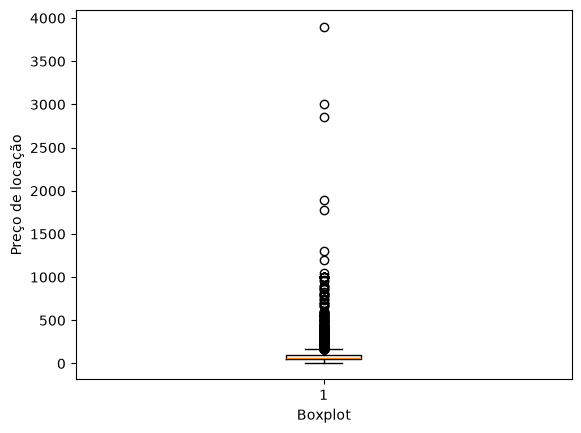

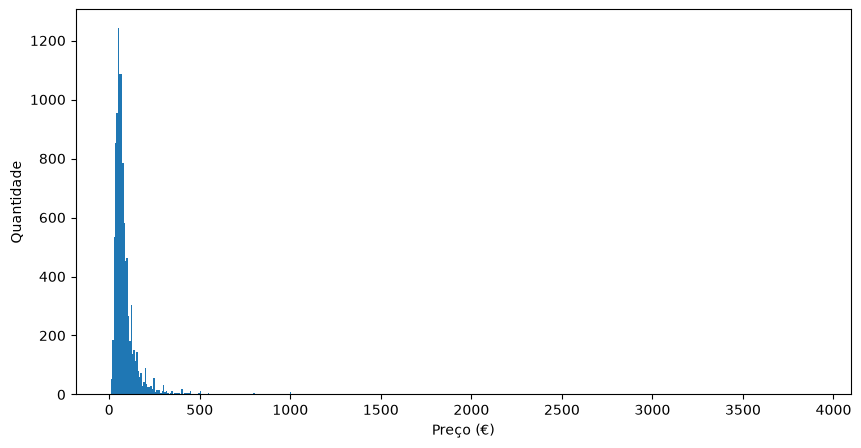

Estadia mínima
    Identificador: minimum_nights
    Tipo: Inteiro
    Quantidade mínima de dias que o hóspede deve contratar de estadia.
    Vazios: 0 de 12044 (0.00%)
    Intervalo numérico: [1, 1125]
    Média: 4.0848555297243445
    Mediana: 2.0
    Desvio padrão: 34.046935670996234
    Percentil 05%: 1.0
    Percentil 25%: 1.0
    Percentil 50%: 2.0
    Percentil 75%: 2.0
    Percentil 95%: 5.0


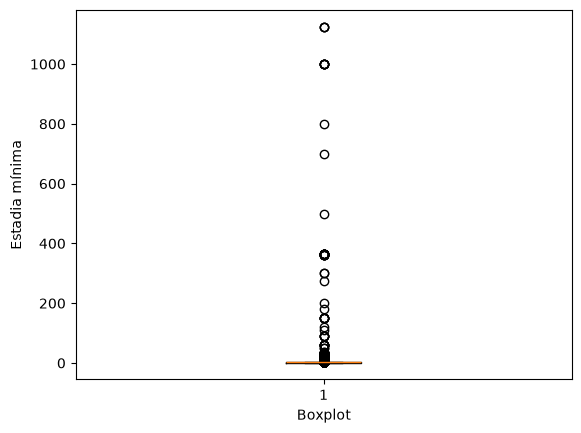

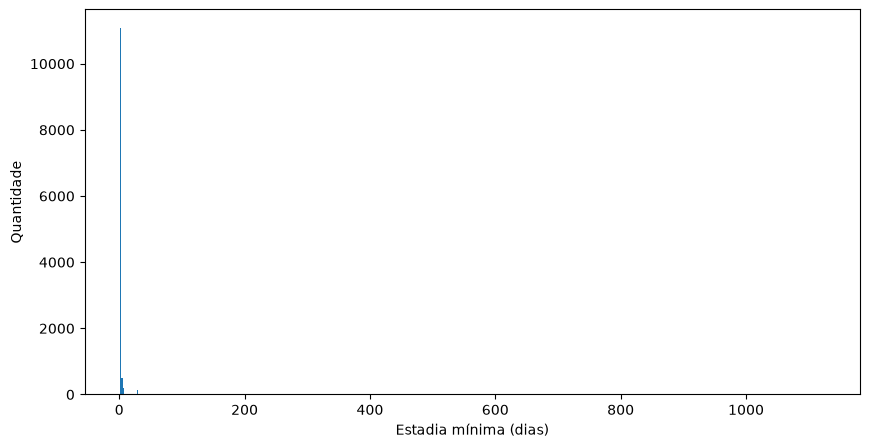

Quantidade de avaliações
    Identificador: number_of_reviews
    Tipo: Inteiro
    Quantidade de avaliações que este anúncio recebeu por meio da plataforma Airbnb.
    Vazios: 0 de 12044 (0.00%)
    Intervalo numérico: [0, 976]
    Média: 76.43839256061109
    Mediana: 36.0
    Desvio padrão: 103.78154024166896
    Percentil 05%: 0.0
    Percentil 25%: 7.0
    Percentil 50%: 36.0
    Percentil 75%: 105.0
    Percentil 95%: 286.85000000000036


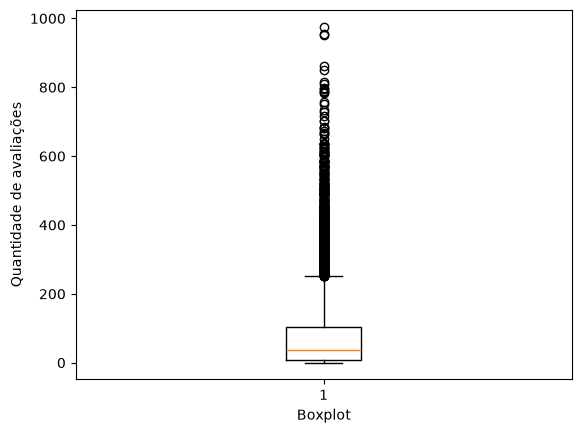

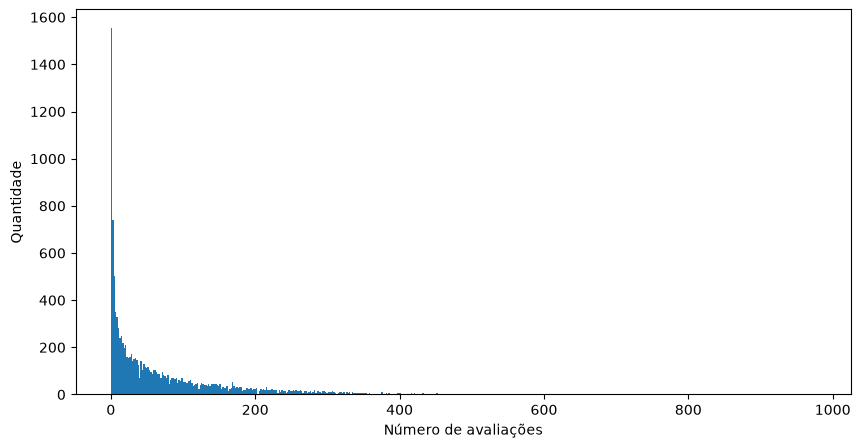

Data da última avaliação
    Identificador: last_review
    Tipo: Data (dia, mês, e ano)
    Data em que a avaliação mais recente deste anúncio foi realizada por meio da plataforma Airbnb.
    Vazios: 1073 de 10971 (9.78%)
    Intervalo numérico: [2013-01-02, 2024-12-14]

Média de avaliações por mês
    Identificador: reviews_per_month
    Tipo: Inteiro
    Quantidade média de avaliações que este anúncio recebeu por mês por meio da plataforma Airbnb.
    Vazios: 1073 de 10971 (9.78%)
    Intervalo numérico: [0.01, 16.43]
    Média: 1.616888159693738
    Mediana: 1.09
    Desvio padrão: 1.5990049823613444
    Percentil 05%: 0.05
    Percentil 25%: 0.33
    Percentil 50%: 1.09
    Percentil 75%: 2.48
    Percentil 95%: 4.89


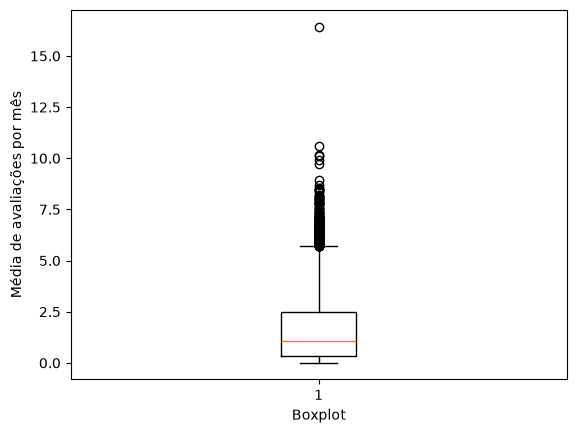

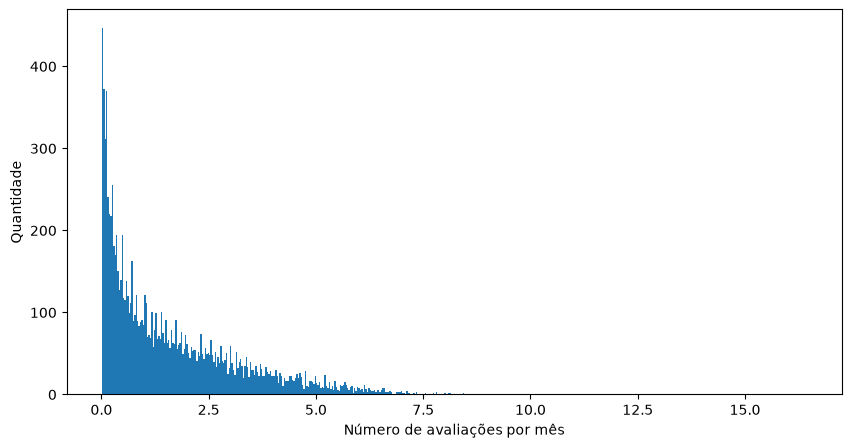

Quantidade de anúncios do anunciante
    Identificador: calculated_host_listings_count
    Tipo: Inteiro
    Quantidade de anúncios que este anunciante realizou na grande região de escopo deste dataset.
    Vazios: 0 de 12044 (0.00%)
    Intervalo numérico: [1, 334]
    Média: 18.3867485885088
    Mediana: 5.0
    Desvio padrão: 43.29776416538993
    Percentil 05%: 1.0
    Percentil 25%: 2.0
    Percentil 50%: 5.0
    Percentil 75%: 13.0
    Percentil 95%: 92.0


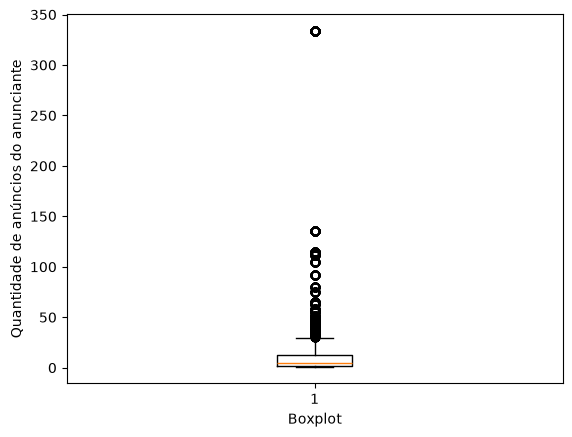

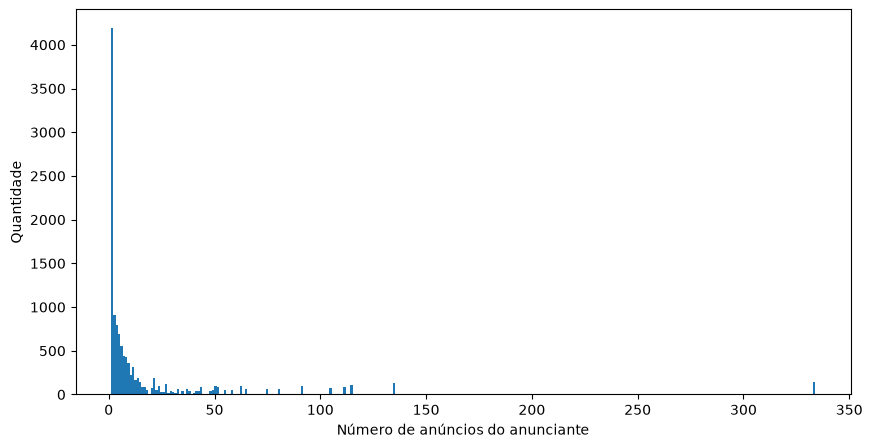

Quantidade de dias disponíveis
    Identificador: availability_365
    Tipo: Inteiro
    Quantidade de dias nos próximos 365 dias em que este anúncio estará disponível para locação.
    Vazios: 0 de 12044 (0.00%)
    Intervalo numérico: [0, 365]
    Média: 234.66722019262704
    Mediana: 286.0
    Desvio padrão: 129.32772094698745
    Percentil 05%: 0.0
    Percentil 25%: 137.0
    Percentil 50%: 286.0
    Percentil 75%: 346.0
    Percentil 95%: 364.0


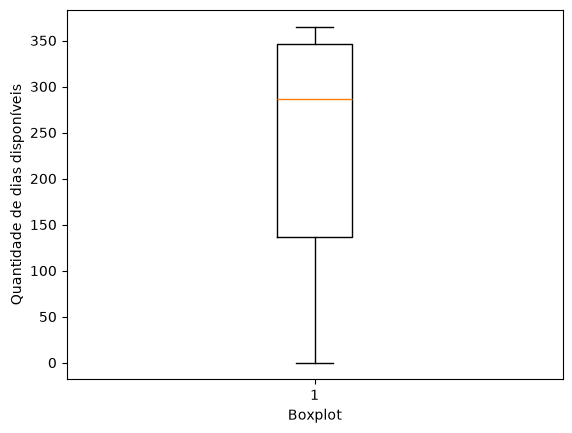

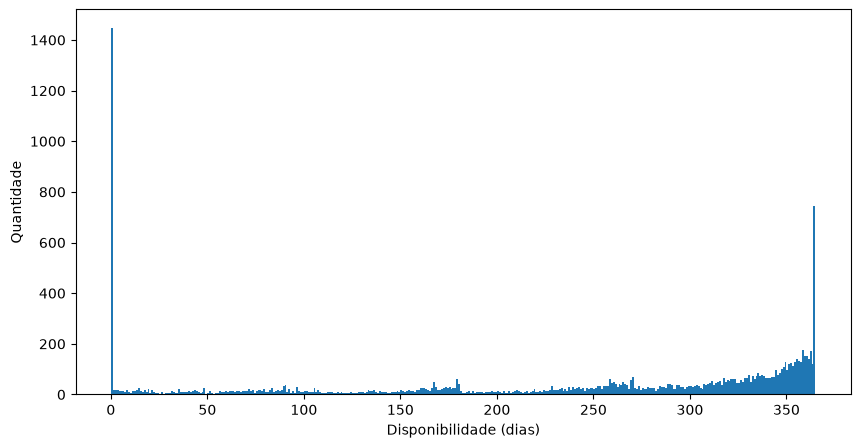

Licença
    Identificador: license
    Tipo: Textual
    Licença de Alojamento Local (AL) obtida para operar a locação do imóvel deste anúncio.
    Vazios: 670 de 11374 (5.89%)



In [177]:
df = pd.read_csv("data/1_Porto.csv")
df["last_review"] = pd.to_datetime(
    df["last_review"], errors="coerce", format="%Y-%m-%d"
)

border_line(6)
print("Colunas")
border_line(6)
print()

column_description(
    name="ID do anúncio",
    series=df.id,
    type_description="Textual (sequência de dígitos)",
    description="Identificador interno dado pelo Airbnb para esta entrada.",
    column_type="other",
)
# Creio ser irrelevante.
print()

column_description(
    name="Nome do anúncio",
    series=df.name,
    type_description="Textual",
    description="Nome dado pelos anunciantes a este anúncio.",
    column_type="other",
)
# Creio ser irrelevante.
print()

column_description(
    name="ID do anunciante",
    series=df.host_id,
    type_description="Textual (sequência de dígitos)",
    description="Identificador interno dado pelo Airbnb para a conta do anunciante que registrou esta entrada.",
    column_type="other",
)
# Creio ser irrelevante.
print()

column_description(
    name="Nome do anunciante",
    series=df.host_name,
    type_description="Textual",
    description="Nome do anunciante que registrou esta entrada. Mesmo quando há mais de uma pessoa, eles são responsáveis pela mesma conta no Airbnb.",
    column_type="other",
)
# Creio ser irrelevante.
print()

column_description(
    name="Município do imóvel",
    series=df.neighbourhood_group,
    type_description="Categórico, não ordenado",
    description="Município em que o imóvel anunciado está localizado. Obtido por meio da localização geográfica.",
    column_type="categorical",
)
df.neighbourhood_group = pd.Categorical(
    df.neighbourhood_group,
    categories=[
        "AROUCA",
        "ESPINHO",
        "GONDOMAR",
        "MAIA",
        "MATOSINHOS",
        "OLIVEIRA DE AZEMÉIS",
        "PAREDES",
        "PORTO",
        "PÓVOA DE VARZIM",
        "SANTA MARIA DA FEIRA",
        "SANTO TIRSO",
        "SÃO JOÃO DA MADEIRA",
        "TROFA",
        "VALE DE CAMBRA",
        "VALONGO",
        "VILA DO CONDE",
        "VILA NOVA DE GAIA",
    ],
    ordered=False,
)
# Quais municípios serão mais baratos?
print()

column_description(
    name="Freguesia do imóvel",
    series=df.neighbourhood,
    type_description="Categórico, não ordenado",
    description="Freguesia em que o imóvel anunciado está localizado. Está dentro de apenas um município.",
    column_type="categorical",
)
df.neighbourhood = pd.Categorical(
    df.neighbourhood,
    categories=[
        "AVer-o-Mar, Amorim e Terroso",
        "Agrela",
        "Aguiar de Sousa",
        "Aguçadoura e Navais",
        "Aldoar, Foz do Douro e Nevogilde",
        "Alfena",
        "Alvarelhos e Guidões",
        "Alvarenga",
        "Anta e Guetim",
        "Arcozelo",
        "Areias, Sequeiró, Lama e Palmeira",
        "Argoncilhe",
        "Arouca e Burgo",
        "Arrifana",
        "Arões",
        "Aveleda",
        "Avintes",
        "Azurara",
        "Baguim do Monte (Rio Tinto)",
        "Bagunte, Ferreiró, Outeiro Maior e Parada",
        "Balazar",
        "Baltar",
        "Bonfim",
        "Bougado (São Martinho e Santiago)",
        "Cabreiros e Albergaria da Serra",
        "Caldas de São Jorge e de Pigeiros",
        "Campanhã",
        "Campo e Sobrado",
        "Canedo, Vale e Vila Maior",
        "Canelas",
        "Canelas e Espiunca",
        "Canidelo",
        "Carregosa",
        "Carreira e Refojos de Riba de Ave",
        "Castêlo da Maia",
        "Cedofeita, Ildefonso, Sé, Miragaia, Nicolau, Vitória",
        "Cepelos",
        "Cesar",
        "Cete",
        "Chave",
        "Cidade da Maia",
        "Coronado (São Romão e São Mamede)",
        "Covelas",
        "Covelo de Paivó e Janarde",
        "Cristelo",
        "Custóias, Leça do Balio e Guifões",
        "Duas Igrejas",
        "Ermesinde",
        "Escariz",
        "Espinho",
        "Estela",
        "Fajões",
        "Fermedo",
        "Fiães",
        "Fornelo e Vairão",
        "Fornos",
        "Foz do Sousa e Covelo",
        "Fânzeres e São Pedro da Cova",
        "Gandra",
        "Gião",
        "Gondomar (São Cosme), Valbom e Jovim",
        "Grijó e Sermonde",
        "Guilhabreu",
        "Gulpilhares e Valadares",
        "Junqueira",
        "Labruge",
        "Laundos",
        "Lobão, Gião, Louredo e Guisande",
        "Lomba",
        "Lordelo do Ouro e Massarelos",
        "Louredo",
        "Lourosa",
        "Macieira da Maia",
        "Macieira de Cambra",
        "Macieira de Sarnes",
        "Madalena",
        "Mafamude e Vilar do Paraíso",
        "Malta e Canidelo",
        "Mansores",
        "Matosinhos e Leça da Palmeira",
        "Melres e Medas",
        "Milheirós",
        "Milheirós de Poiares",
        "Mindelo",
        "Moldes",
        "Monte Córdova",
        "Moreira",
        "Mozelos",
        "Muro",
        "Negrelos (São Tomé)",
        "Nogueira da Regedoura",
        "Nogueira do Cravo e Pindelo",
        "Nogueira e Silva Escura",
        "O. Azeméis, Riba-Ul, Ul, Macinhata da Seixa, Madail",
        "Oliveira do Douro",
        "Ossela",
        "Parada de Todeia",
        "Paramos",
        "Paranhos",
        "Paredes",
        "Paços de Brandão",
        "Pedroso e Seixezelo",
        "Pedrouços",
        "Perafita, Lavra e Santa Cruz do Bispo",
        "Pinheiro da Bemposta, Travanca e Palmaz",
        "Póvoa de Varzim, Beiriz e Argivai",
        "Ramalde",
        "Rates",
        "Rebordosa",
        "Reguenga",
        "Retorta e Tougues",
        "Rio Mau e Arcos",
        "Rio Tinto",
        "Roge",
        "Romariz",
        "Roriz",
        "Rossas",
        "Sandim, Olival, Lever e Crestuma",
        "Sanguedo",
        "Santa Eulália",
        "Santa Maria da Feira, Travanca, Sanfins e Espargo",
        "Santa Maria de Lamas",
        "Santa Marinha e São Pedro da Afurada",
        "Serzedo e Perosinho",
        "Silvalde",
        "Sobreira",
        "St. Tirso, Couto (S. Cristina e S. Miguel) e Burgães",
        "São Félix da Marinha",
        "São João da Madeira",
        "São Mamede de Infesta e Senhora da Hora",
        "São Martinho da Gândara",
        "São Miguel do Mato",
        "São Pedro Fins",
        "São Pedro de Castelões",
        "São Roque",
        "Touguinha e Touguinhó",
        "Tropeço",
        "Urrô",
        "Valongo",
        "Vandoma",
        "Vila Chã",
        "Vila Chã, Codal e Vila Cova de Perrinho",
        "Vila Nova da Telha",
        "Vila Nova do Campo",
        "Vila de Cucujães",
        "Vila do Conde",
        "Vilar de Andorinho",
        "Vilar de Pinheiro",
        "Vilar e Mosteiró",
        "Vilarinho",
        "Vilela",
        "Várzea",
        "Água Longa",
        "Águas Santas",
        "Árvore",
    ],
    ordered=False,
)
# Quais freguesias serão mais baratas?
print()

column_description(
    name="Latitude do imóvel",
    series=df.latitude,
    type_description="Real",
    description="Latitude da localização do imóvel anunciado conforme o World Geodetic System (WGS84).",
    column_type="other",
)
# Creio ser menos relevante do que a freguesia calculada.
print()

column_description(
    name="Longitude do imóvel",
    series=df.longitude,
    type_description="Real",
    description="Longitude da localização do imóvel anunciado conforme o World Geodetic System (WGS84).",
    column_type="other",
)
# Creio ser menos relevante do que a freguesia calculada.
print()

column_description(
    name="Tipo de locação",
    series=df.room_type,
    type_description="Categórico, não ordenado",
    description="Tipo da locação sendo anunciada. Especifica quais áreas do imóvel o inquilino poderá acessar.",
    column_type="categorical",
)
df.room_type = pd.Categorical(
    df.room_type,
    categories=["Entire home/apt", "Hotel room", "Private room", "Shared room"],
    ordered=False,
)
# Um imóvel menor (quarto) será mais barato?
print()

column_description(
    name="Preço de locação",
    series=df.price,
    type_description="Real",
    description="Preço diário de locação deste anúncio em euros.",
    column_type="numerical",
)
print()
generate_histogram(series=df.price, label="Preço (€)")

column_description(
    name="Estadia mínima",
    series=df.minimum_nights,
    type_description="Inteiro",
    description="Quantidade mínima de dias que o hóspede deve contratar de estadia.",
    column_type="numerical",
)
# Um anúncio com estadia longa será mais barato?
print()
generate_histogram(series=df.minimum_nights, label="Estadia mínima (dias)")


column_description(
    name="Quantidade de avaliações",
    series=df.number_of_reviews,
    type_description="Inteiro",
    description="Quantidade de avaliações que este anúncio recebeu por meio da plataforma Airbnb.",
    column_type="numerical",
)
# Um anúncio muito avaliado será mais barato?
print()
generate_histogram(series=df.number_of_reviews, label="Número de avaliações")

column_description(
    name="Data da última avaliação",
    series=df.last_review,
    type_description="Data (dia, mês, e ano)",
    description="Data em que a avaliação mais recente deste anúncio foi realizada por meio da plataforma Airbnb.",
    column_type="date",
)
# Creio não ter muita relevância.
print()

column_description(
    name="Média de avaliações por mês",
    series=df.reviews_per_month,
    type_description="Inteiro",
    description="Quantidade média de avaliações que este anúncio recebeu por mês por meio da plataforma Airbnb.",
    column_type="numerical",
)
# Um anúncio com muitas avaliações será mais barato?
print()
generate_histogram(series=df.reviews_per_month, label="Número de avaliações por mês")

column_description(
    name="Quantidade de anúncios do anunciante",
    series=df.calculated_host_listings_count,
    type_description="Inteiro",
    description="Quantidade de anúncios que este anunciante realizou na grande região de escopo deste dataset.",
    column_type="numerical",
)
# Um anunciante que publica muitos anúncios será mais barato?
print()
generate_histogram(
    series=df.calculated_host_listings_count,
    label="Número de anúncios do anunciante",
    bins=300,
)

column_description(
    name="Quantidade de dias disponíveis",
    series=df.availability_365,
    type_description="Inteiro",
    description="Quantidade de dias nos próximos 365 dias em que este anúncio estará disponível para locação.",
    column_type="numerical",
)
# Um imóvel com disponibilidade alta será mais barato?
print()
generate_histogram(series=df.availability_365, label="Disponibilidade (dias)", bins=365)

column_description(
    name="Licença",
    series=df.license,
    type_description="Textual",
    description="Licença de Alojamento Local (AL) obtida para operar a locação do imóvel deste anúncio.",
    column_type="other",
)
# Um imóvel sem licença registrada ou isento de licença será mais barato?
print()


In [178]:
print(f"{open_bold}Remoção de entradas{close_bold}")

empty_amount_of_price = df.price.isna().sum()
total_amount_of_price = df.price.size
not_empty_amount_of_price = total_amount_of_price - empty_amount_of_price
print(
    f"""O objetivo do modelo é estimar o {open_bold}preço de hospedagem por dia{close_bold} (em euros).
Logo, não faz sentido completar os dados faltantes na coluna {open_bold}price{close_bold}.
Assim, as {empty_amount_of_price} entradas vazias foram eliminadas, restando {open_bold}{not_empty_amount_of_price}{close_bold} entradas ({(empty_amount_of_price / total_amount_of_price):.2%} / {(not_empty_amount_of_price / total_amount_of_price):.2%}).""",
)
df = df.dropna(subset=["price"])


Remoção de entradas
O objetivo do modelo é estimar o preço de hospedagem por dia (em euros).
Logo, não faz sentido completar os dados faltantes na coluna price.
Assim, as 1593 entradas vazias foram eliminadas, restando 10451 entradas (13.23% / 86.77%).


In [179]:
print(f"{open_bold}Remoção de duplicatas{close_bold}")

print("São consideradas entradas duplicadas aquelas:")
print(
    textwrap.indent(
        'que compartilham Nome, ID do anunciante, Licença;\ne que sejam de tipo "Entire home/apt",\npois quartos individuais podem ser anúncios separados de um mesmo apartamento ou casa.',
        indentation,
    )
)
print(
    f"\nPara as duplicatas, será mantida a que tenha a maior quantidade de {open_bold}colunas preenchidas{close_bold}.\nEm caso de empate, considerar-se-á aquela com maior quantidade de {open_bold}avaliações{close_bold}."
)

total_amount = df.id.size

entire_home_mask = df["room_type"].eq("Entire home/apt")
has_license_mask = df["license"].notna()
duplicated_mask = (
    entire_home_mask
    & has_license_mask
    & df.duplicated(subset=["host_id", "name", "license"], keep=False)
)

df[duplicated_mask].sort_values(["host_id", "name", "license"])

df_selected = df[duplicated_mask].copy()
df_not_selected = df[~duplicated_mask].copy()

df_selected["filled_columns"] = df_selected.notna().sum(axis=1)
df_selected = df_selected.sort_values(
    ["host_id", "name", "license", "filled_columns", "number_of_reviews"],
    ascending=[True, True, True, False, False],
).drop_duplicates(subset=["host_id", "name", "license"], keep="first")

df = pd.concat([df_selected, df_not_selected], ignore_index=True)
df = df.drop(columns="filled_columns")

remaining_amount = df.id.size
removed_amount = total_amount - remaining_amount

print(
    f"\nEliminadas {total_amount - remaining_amount} entradas de {total_amount} ({(removed_amount / total_amount):.2%} / {(remaining_amount / total_amount):.2%})."
)


Remoção de duplicatas
São consideradas entradas duplicadas aquelas:
    que compartilham Nome, ID do anunciante, Licença;
    e que sejam de tipo "Entire home/apt",
    pois quartos individuais podem ser anúncios separados de um mesmo apartamento ou casa.

Para as duplicatas, será mantida a que tenha a maior quantidade de colunas preenchidas.
Em caso de empate, considerar-se-á aquela com maior quantidade de avaliações.

Eliminadas 46 entradas de 10451 (0.44% / 99.56%).
